# Experiment: k-Reciprocal Re-Ranking for Jaguar Re-Identification

This notebook builds on the **baseline pipeline** (MegaDescriptor + ArcFace) and introduces **k-reciprocal re-ranking** as a post-processing step to improve retrieval quality.

## Hypothesis
Applying k-reciprocal re-ranking (Zhong et al., CVPR 2017) to the fine-tuned ArcFace embeddings will improve validation mAP compared to using raw cosine similarity alone, by leveraging the neighborhood structure of the embedding space.

## Method: k-Reciprocal Re-Ranking
Instead of using raw cosine similarity for each query-gallery pair, we:
1. Compute initial pairwise distances between all embeddings
2. Find k-reciprocal nearest neighbors (mutual nearest neighbors)
3. Encode each image by its k-reciprocal neighbor set (Jaccard distance)
4. Combine the original distance with the Jaccard distance for a refined similarity

This technique exploits the **global structure** of the embedding space: if two images share similar neighborhoods, they are more likely to be the same identity — even if their direct similarity is not the highest.

## Key Difference to Baseline
The baseline computes `similarity = dot_product(query_emb, gallery_emb)` for each pair independently. This experiment adds a **re-ranking post-processing step** that refines similarities using the neighborhood structure across ALL test embeddings. The training pipeline (MegaDescriptor → ArcFace) is **identical** to the baseline.

## Comparability
- Same model architecture (MegaDescriptor-L-384 → EmbeddingProjection → ArcFace)
- Same hyperparameters (lr, epochs, batch_size, ArcFace margin/scale, etc.)
- Same train/val split (stratified, seed=42)
- Same W&B logging
- **Only difference**: Post-processing of similarity scores via k-reciprocal re-ranking

## Reference
Zhong, Z., Zheng, L., Cao, D., & Li, S. (2017). *Re-ranking Person Re-identification with k-Reciprocal Encoding*. CVPR 2017.

## 1. Setup and Configuration

In [1]:
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import timm
from torchvision import transforms
from PIL import Image
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_similarity
import math
import random
import wandb
from dotenv import load_dotenv

# Load environment variables from .env file
env_path = Path("../../.env")
if env_path.exists():
    load_dotenv(env_path)
    print(f"Loaded environment variables from {env_path}")
else:
    print(f"Warning: {env_path} not found. Set WANDB_API_KEY and HF_TOKEN manually.")

try:
    from kaggle_secrets import UserSecretsClient
    user_secrets = UserSecretsClient()
    os.environ["HF_TOKEN"] = user_secrets.get_secret("hf_api")
    os.environ["WANDB_API_KEY"] = user_secrets.get_secret("wandb_api")
except ImportError:
    print("Not running on Kaggle, using local .env for secrets.")

# Set random seeds for reproducibility
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"PyTorch version: {torch.__version__}")
print(f"timm version: {timm.__version__}")

# Device configuration
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

print(f"Device: {device}")

PyTorch version: 2.9.0+cu126
timm version: 1.0.24
Using CUDA GPU
Device: cuda


In [2]:
# Configuration – IDENTICAL to baseline for fair comparison
config = {
    # Paths
    "data_dir": Path("/kaggle/input/competitions/jaguar-re-id"),
    "checkpoint_dir": Path("checkpoints_reranking"),

    # Model
    "megadescriptor_model": "hf-hub:BVRA/MegaDescriptor-L-384",
    "input_size": 384,
    "embedding_dim": 256,
    "hidden_dim": 512,

    # ArcFace
    "arcface_margin": 0.5,
    "arcface_scale": 64.0,
    "dropout": 0.3,

    # Training
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,
    "num_epochs": 50,
    "patience": 10,
    "val_split": 0.2,

    # Re-Ranking hyperparameters
    "rerank_k1": 20,         # k for k-reciprocal nearest neighbors
    "rerank_k2": 6,          # k for local query expansion
    "rerank_lambda": 0.3,    # weight for original distance (1-lambda for Jaccard)

    # Reproducibility
    "seed": RANDOM_SEED,
}

# Handle local vs Kaggle paths
if not config["data_dir"].exists():
    local_data = Path("../data")
    if local_data.exists():
        config["data_dir"] = local_data
        print(f"Using local data directory: {config['data_dir']}")

# Create checkpoint directory
config["checkpoint_dir"].mkdir(exist_ok=True)

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  data_dir: /kaggle/input/competitions/jaguar-re-id
  checkpoint_dir: checkpoints_reranking
  megadescriptor_model: hf-hub:BVRA/MegaDescriptor-L-384
  input_size: 384
  embedding_dim: 256
  hidden_dim: 512
  arcface_margin: 0.5
  arcface_scale: 64.0
  dropout: 0.3
  batch_size: 32
  learning_rate: 0.0001
  weight_decay: 0.0001
  num_epochs: 50
  patience: 10
  val_split: 0.2
  rerank_k1: 20
  rerank_k2: 6
  rerank_lambda: 0.3
  seed: 42


In [3]:
# Initialize Weights and Biases for experiment tracking
wandb.login(key=os.environ["WANDB_API_KEY"])

wandb.init(
    project=os.getenv("WANDB_PROJECT", "jaguar-reid-baseline"),
    config={
        # Model architecture
        "megadescriptor_model": config["megadescriptor_model"],
        "embedding_dim": config["embedding_dim"],
        "hidden_dim": config["hidden_dim"],
        "dropout": config["dropout"],

        # ArcFace hyperparameters
        "arcface_margin": config["arcface_margin"],
        "arcface_scale": config["arcface_scale"],

        # Training hyperparameters
        "batch_size": config["batch_size"],
        "learning_rate": config["learning_rate"],
        "weight_decay": config["weight_decay"],
        "num_epochs": config["num_epochs"],
        "patience": config["patience"],
        "val_split": config["val_split"],
        "seed": config["seed"],

        # Re-Ranking hyperparameters
        "rerank_k1": config["rerank_k1"],
        "rerank_k2": config["rerank_k2"],
        "rerank_lambda": config["rerank_lambda"],

        # Experiment metadata
        "experiment_type": "post-processing",
        "experiment_name": "k-reciprocal-reranking",
    },
    name="reranking-k1_20-k2_6-lambda_0.3",
)

print("W&B initialized. Key hyperparameters tracked:")
print(f"  Project: {os.getenv('WANDB_PROJECT', 'jaguar-reid-baseline')}")
print(f"  Re-Ranking k1: {config['rerank_k1']}")
print(f"  Re-Ranking k2: {config['rerank_k2']}")
print(f"  Re-Ranking lambda: {config['rerank_lambda']}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: finnfrei (finnfreiheit) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run rcw4tjo9
wandb: Tracking run with wandb version 0.24.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260310_160148-rcw4tjo9
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run reranking-k1_20-k2_6-lambda_0.3
wandb: ⭐️ View project at https://wandb.ai/finnfreiheit/jaguar-reid-baseline
wandb: 🚀 View run at https://wandb.ai/finnfreiheit/jaguar-reid-baseline/runs/rcw4tjo9


W&B initialized. Key hyperparameters tracked:
  Project: jaguar-reid-baseline
  Re-Ranking k1: 20
  Re-Ranking k2: 6
  Re-Ranking lambda: 0.3


## 2. Load and Prepare Data

In [4]:
# Load training data
train_df = pd.read_csv(config["data_dir"] / "train.csv")

print(f"Training dataset:")
print(f"  Total images: {len(train_df)}")
print(f"  Unique identities: {train_df['ground_truth'].nunique()}")

# Encode labels to integers
label_encoder = LabelEncoder()
train_df['label_encoded'] = label_encoder.fit_transform(train_df['ground_truth'])
num_classes = len(label_encoder.classes_)

# Stratified split
train_data, val_data = train_test_split(
    train_df,
    test_size=config["val_split"],
    random_state=config["seed"],
    stratify=train_df['ground_truth']
)

print(f"\nDataset split:")
print(f"  Training:   {len(train_data)} images ({100*(1-config['val_split']):.0f}%)")
print(f"  Validation: {len(val_data)} images ({100*config['val_split']:.0f}%)")
print(f"  Num classes: {num_classes}")

# Verify all identities are in both sets
train_identities = set(train_data['ground_truth'].unique())
val_identities = set(val_data['ground_truth'].unique())
if train_identities == val_identities:
    print("  All identities present in both sets ✓")

Training dataset:
  Total images: 1895
  Unique identities: 31

Dataset split:
  Training:   1516 images (80%)
  Validation: 379 images (20%)
  Num classes: 31
  All identities present in both sets ✓


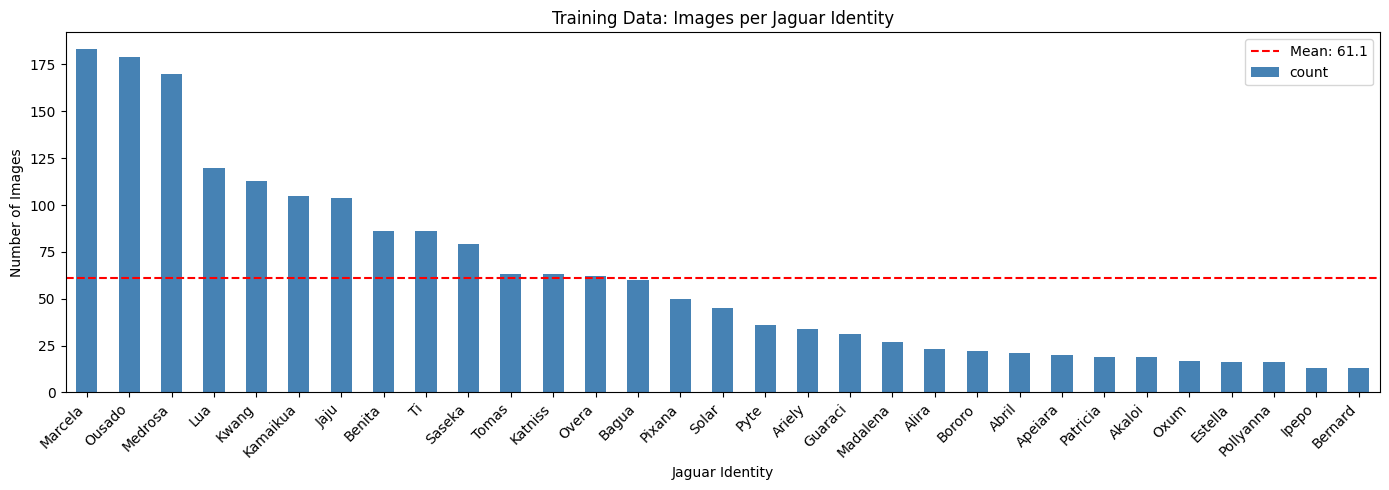

In [5]:
# Visualize identity distribution and log to W&B
identity_counts = train_df['ground_truth'].value_counts()

fig, ax = plt.subplots(figsize=(14, 5))
identity_counts.plot(kind='bar', ax=ax, color='steelblue')
ax.set_xlabel('Jaguar Identity')
ax.set_ylabel('Number of Images')
ax.set_title('Training Data: Images per Jaguar Identity')
ax.axhline(y=identity_counts.mean(), color='red', linestyle='--', label=f'Mean: {identity_counts.mean():.1f}')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
wandb.log({"identity_distribution_full": wandb.Image(fig)})
plt.show()

## 3. Load MegaDescriptor and Extract Embeddings

In [6]:
# Load MegaDescriptor model
print("Loading MegaDescriptor-L-384 model...")
megadescriptor = timm.create_model(
    config["megadescriptor_model"],
    pretrained=True
)
megadescriptor.eval()
megadescriptor.to(device)

print(f"Model loaded successfully")
print(f"  Parameters: {sum(p.numel() for p in megadescriptor.parameters()):,}")

# Get the embedding dimension
with torch.no_grad():
    dummy_input = torch.randn(1, 3, config["input_size"], config["input_size"]).to(device)
    dummy_output = megadescriptor(dummy_input)
    megadescriptor_dim = dummy_output.shape[1]
    print(f"  Embedding dimension: {megadescriptor_dim}")

Loading MegaDescriptor-L-384 model...


config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.94G [00:00<?, ?B/s]

Model loaded successfully
  Parameters: 195,198,516
  Embedding dimension: 1536


In [7]:
# Define preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Resize((config["input_size"], config["input_size"])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

@torch.no_grad()
def extract_embeddings(model, image_paths, batch_size=32, desc="Extracting embeddings"):
    """Extract embeddings for a list of image paths using MegaDescriptor."""
    model.eval()
    embeddings = []

    for i in tqdm(range(0, len(image_paths), batch_size), desc=desc):
        batch_paths = image_paths[i:i + batch_size]

        batch_tensors = []
        for path in batch_paths:
            try:
                img = Image.open(path).convert("RGB")
                tensor = preprocess(img)
                batch_tensors.append(tensor)
            except Exception as e:
                print(f"Error loading {path}: {e}")
                batch_tensors.append(torch.zeros(3, config["input_size"], config["input_size"]))

        batch_tensor = torch.stack(batch_tensors).to(device)
        batch_emb = model(batch_tensor).cpu().numpy()
        embeddings.append(batch_emb)

    return np.vstack(embeddings)

print("Embedding extraction function defined")

Embedding extraction function defined


In [8]:
# Extract embeddings for train and validation sets
emb_dir = Path("/kaggle/working/embeddings")
emb_dir.mkdir(parents=True, exist_ok=True)

cache_path = emb_dir / "baseline_train_embeddings.npz"

train_filenames = train_data["filename"].astype(str).tolist()
train_image_paths = [config["data_dir"] / "train/train" / fn for fn in train_filenames]

def _load_cached_embeddings(cache_path, expected_filenames):
    z = np.load(cache_path, allow_pickle=True)
    cached_embeddings = z["embeddings"]
    cached_filenames = z["filenames"].tolist() if isinstance(z["filenames"], np.ndarray) else list(z["filenames"])
    if len(cached_filenames) != len(expected_filenames):
        return None
    if set(cached_filenames) != set(expected_filenames):
        return None
    if cached_filenames == expected_filenames:
        return cached_embeddings
    idx = {fn: i for i, fn in enumerate(cached_filenames)}
    return np.stack([cached_embeddings[idx[fn]] for fn in expected_filenames], axis=0)

baseline_train_embeddings = None
if cache_path.exists():
    baseline_train_embeddings = _load_cached_embeddings(cache_path, train_filenames)
    if baseline_train_embeddings is not None:
        print(f"Loaded cached baseline embeddings from {cache_path}")

if baseline_train_embeddings is None:
    print(f"Extracting baseline embeddings for {len(train_image_paths)} training images...")
    baseline_train_embeddings = extract_embeddings(
        megadescriptor, train_image_paths, batch_size=config["batch_size"]
    )
    np.savez_compressed(
        cache_path,
        embeddings=baseline_train_embeddings,
        filenames=np.array(train_filenames, dtype=object),
    )
    print(f"Saved baseline embeddings cache to {cache_path}")

print(f"Baseline train embeddings shape: {baseline_train_embeddings.shape}")

# Extract validation embeddings
val_image_paths = [
    config["data_dir"] / "train/train" / filename
    for filename in val_data['filename'].values
]

print(f"Extracting embeddings for {len(val_image_paths)} validation images...")
baseline_val_embeddings = extract_embeddings(
    megadescriptor, val_image_paths, batch_size=config["batch_size"]
)
print(f"Validation embeddings shape: {baseline_val_embeddings.shape}")

Extracting baseline embeddings for 1516 training images...


Extracting embeddings:   0%|          | 0/48 [00:00<?, ?it/s]

Saved baseline embeddings cache to /kaggle/working/embeddings/baseline_train_embeddings.npz
Baseline train embeddings shape: (1516, 1536)
Extracting embeddings for 379 validation images...


Extracting embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Validation embeddings shape: (379, 1536)


## 4. Model Architecture (Identical to Baseline)

In [9]:
class EmbeddingProjection(nn.Module):
    """Projects MegaDescriptor embeddings to a lower-dimensional space."""

    def __init__(self, input_dim=1536, hidden_dim=512, output_dim=256, dropout=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
            nn.BatchNorm1d(output_dim),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        return self.network(x)


class ArcFaceLayer(nn.Module):
    """ArcFace (Additive Angular Margin Loss) layer."""

    def __init__(self, embedding_dim, num_classes, margin=0.5, scale=64.0):
        super().__init__()
        self.embedding_dim = embedding_dim
        self.num_classes = num_classes
        self.margin = margin
        self.scale = scale
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_dim))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th = math.cos(math.pi - margin)
        self.mm = math.sin(math.pi - margin) * margin

    def forward(self, embeddings, labels):
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)
        cosine = F.linear(embeddings, weight_norm)
        cosine = cosine.clamp(-1.0, 1.0)
        sine = torch.sqrt(1.0 - torch.pow(cosine, 2))
        phi = cosine * self.cos_m - sine * self.sin_m
        phi = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros(cosine.size(), device=embeddings.device)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)
        output = (one_hot * phi) + ((1.0 - one_hot) * cosine)
        output = output * self.scale
        return output


class ArcFaceModel(nn.Module):
    """Complete model: Embedding Projection + ArcFace."""

    def __init__(self, input_dim, num_classes, embedding_dim=256, hidden_dim=512, margin=0.5, scale=64.0, dropout=0.3):
        super().__init__()
        self.embedding_net = EmbeddingProjection(
            input_dim=input_dim, hidden_dim=hidden_dim,
            output_dim=embedding_dim, dropout=dropout
        )
        self.arcface = ArcFaceLayer(
            embedding_dim=embedding_dim, num_classes=num_classes,
            margin=margin, scale=scale
        )

    def forward(self, x, labels):
        embeddings = self.embedding_net(x)
        logits = self.arcface(embeddings, labels)
        return logits, embeddings

    def get_embeddings(self, x):
        embeddings = self.embedding_net(x)
        return F.normalize(embeddings, p=2, dim=1)


# Create model
model = ArcFaceModel(
    input_dim=megadescriptor_dim,
    num_classes=num_classes,
    embedding_dim=config["embedding_dim"],
    hidden_dim=config["hidden_dim"],
    margin=config["arcface_margin"],
    dropout=config["dropout"],
).to(device)

# Log num parameters
num_params = sum(p.numel() for p in model.parameters())
wandb.log({"num_parameters": num_params})

print(f"ArcFace Model:")
print(f"  Input dim: {megadescriptor_dim}")
print(f"  Hidden dim: {config['hidden_dim']}")
print(f"  Embedding dim: {config['embedding_dim']}")
print(f"  Num classes: {num_classes}")
print(f"  Total parameters: {num_params:,}")

ArcFace Model:
  Input dim: 1536
  Hidden dim: 512
  Embedding dim: 256
  Num classes: 31
  Total parameters: 927,744


## 5. Prepare DataLoaders

In [10]:
class EmbeddingDataset(Dataset):
    """PyTorch Dataset for pre-computed embeddings."""

    def __init__(self, embeddings, labels):
        self.embeddings = torch.FloatTensor(embeddings)
        self.labels = torch.LongTensor(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.embeddings[idx], self.labels[idx]


train_dataset = EmbeddingDataset(baseline_train_embeddings, train_data['label_encoded'].values)
val_dataset = EmbeddingDataset(baseline_val_embeddings, val_data['label_encoded'].values)

train_loader = DataLoader(train_dataset, batch_size=config["batch_size"], shuffle=True, num_workers=0, pin_memory=False)
val_loader = DataLoader(val_dataset, batch_size=config["batch_size"], shuffle=False, num_workers=0, pin_memory=False)

print(f"DataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")

DataLoaders created:
  Train batches: 48
  Val batches: 12


## 6. Training Setup and Validation mAP

In [11]:
def compute_validation_map(model, val_embeddings, val_labels, label_encoder):
    """Compute identity-balanced mean Average Precision on validation set."""
    model.eval()

    with torch.no_grad():
        val_tensor = torch.FloatTensor(val_embeddings).to(device)
        finetuned_emb = model.get_embeddings(val_tensor).cpu().numpy()

    sim_matrix = cosine_similarity(finetuned_emb)
    np.fill_diagonal(sim_matrix, -1)

    query_aps = {}
    for query_idx in range(len(val_labels)):
        query_label = val_labels[query_idx]
        similarities = sim_matrix[query_idx]
        gallery_labels = val_labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0

        sorted_indices = np.argsort(-similarities)
        sorted_matches = is_match[sorted_indices]

        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue

        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives
        query_aps[query_idx] = (query_label, ap)

    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)

    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    balanced_map = np.mean(identity_mean_aps)
    return balanced_map


print("Validation mAP function defined")

Validation mAP function defined


In [12]:
# Setup training components
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"]
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5,
)

print("Training components initialized")

Training components initialized


In [13]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Training', leave=False)
    for embeddings, labels in pbar:
        embeddings, labels = embeddings.to(device), labels.to(device)
        logits, _ = model(embeddings, labels)
        loss = criterion(logits, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        _, predicted = torch.max(logits.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})

    return total_loss / len(loader), 100. * correct / total


def validate_epoch(model, loader, criterion, device):
    """Validate for one epoch."""
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation', leave=False)
        for embeddings, labels in pbar:
            embeddings, labels = embeddings.to(device), labels.to(device)
            logits, _ = model(embeddings, labels)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.1f}%'})

    return total_loss / len(loader), 100. * correct / total


print("Training and validation functions defined")

Training and validation functions defined


## 7. Training Loop (Identical to Baseline)

In [14]:
# Training loop
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss': [], 'val_acc': [],
    'val_map': [], 'lr': []
}

best_val_loss = float('inf')
best_map = 0.0
patience_counter = 0
best_epoch = 0

print(f"Starting training for {config['num_epochs']} epochs...")
print("=" * 70)

for epoch in range(config['num_epochs']):
    print(f"\nEpoch {epoch+1}/{config['num_epochs']}")

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

    # Compute validation mAP
    val_map = compute_validation_map(
        model, baseline_val_embeddings,
        val_data['ground_truth'].values, label_encoder
    )

    # Update scheduler
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_map'].append(val_map)
    history['lr'].append(current_lr)

    wandb.log({
        'epoch': epoch + 1,
        'train_loss': train_loss, 'train_acc': train_acc,
        'val_loss': val_loss, 'val_acc': val_acc,
        'val_map': val_map, 'learning_rate': current_lr,
    })

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.1f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.1f}%")
    print(f"  Val mAP:    {val_map:.4f} | LR: {current_lr:.2e}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_map = val_map
        best_epoch = epoch + 1
        patience_counter = 0

        checkpoint_path = config["checkpoint_dir"] / "arcface_best.pth"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_map': val_map,
            'config': config,
            'label_encoder_classes': label_encoder.classes_.tolist(),
            'num_classes': num_classes,
        }, checkpoint_path)
        print(f"  [New best model saved]")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{config['patience']}")

    if patience_counter >= config['patience']:
        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        break

print("\n" + "=" * 70)
print(f"Training complete!")
print(f"Best epoch: {best_epoch} (Val Loss: {best_val_loss:.4f}, Val mAP: {best_map:.4f})")

wandb.run.summary["best_val_mAP_baseline"] = best_map
wandb.run.summary["best_val_loss"] = best_val_loss
wandb.run.summary["best_epoch"] = best_epoch
wandb.run.summary["total_epochs"] = len(history['train_loss'])

Starting training for 50 epochs...

Epoch 1/50


Training:   0%|          | 0/48 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

  Train Loss: 36.6027 | Train Acc: 0.0%
  Val Loss:   31.7337 | Val Acc:   0.0%
  Val mAP:    0.3516 | LR: 1.00e-04
  [New best model saved]

Epoch 2/50


Training:   0%|          | 0/48 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

  Train Loss: 0.8481 | Train Acc: 88.2%
  Val Loss:   4.7882 | Val Acc:   82.1%
  Val mAP:    0.7726 | LR: 1.00e-04
  [New best model saved]

Epoch 50/50


Training:   0%|          | 0/48 [00:00<?, ?it/s]

Validation:   0%|          | 0/12 [00:00<?, ?it/s]

  Train Loss: 0.7091 | Train Acc: 88.8%
  Val Loss:   4.8231 | Val Acc:   81.5%
  Val mAP:    0.7741 | LR: 1.00e-04
  No improvement. Patience: 1/10

Training complete!
Best epoch: 49 (Val Loss: 4.7882, Val mAP: 0.7726)


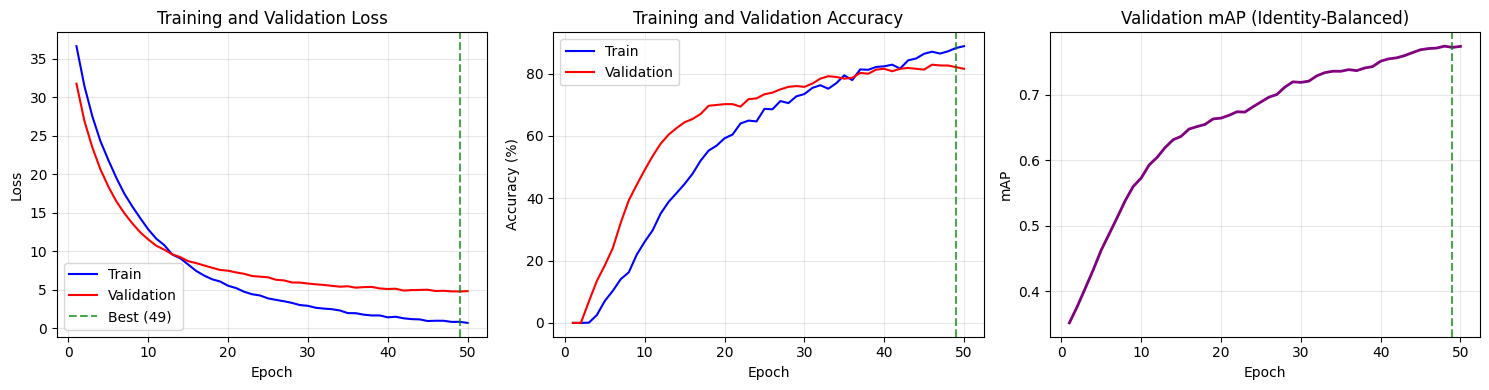

In [15]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], 'b-', label='Train')
axes[0].plot(epochs_range, history['val_loss'], 'r-', label='Validation')
axes[0].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7, label=f'Best ({best_epoch})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], 'b-', label='Train')
axes[1].plot(epochs_range, history['val_acc'], 'r-', label='Validation')
axes[1].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(epochs_range, history['val_map'], 'purple', linewidth=2)
axes[2].axvline(x=best_epoch, color='g', linestyle='--', alpha=0.7)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('mAP')
axes[2].set_title('Validation mAP (Identity-Balanced)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(config["checkpoint_dir"] / 'training_curves.png', dpi=150, bbox_inches='tight')
wandb.log({"training_curves": wandb.Image(fig)})
plt.show()

In [16]:
# Load best model
checkpoint = torch.load(config["checkpoint_dir"] / "arcface_best.pth", map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val mAP: {checkpoint['val_map']:.4f}")

Loaded best model from epoch 49
  Val Loss: 4.7882
  Val mAP: 0.7726


## 8. k-Reciprocal Re-Ranking Implementation

This is the **core contribution** of this experiment. We implement the k-reciprocal re-ranking algorithm from Zhong et al. (CVPR 2017), adapted for our jaguar re-identification task.

### Algorithm Overview

Given a distance matrix $D$ between all embeddings:

1. **k-Nearest Neighbors**: For each probe $p$, find its $k_1$ nearest neighbors $N(p, k_1)$
2. **k-Reciprocal Neighbors**: $R(p, k_1) = \{g_i \mid g_i \in N(p, k_1) \land p \in N(g_i, k_1)\}$  
   → Only keep neighbors that also consider $p$ as their neighbor
3. **Local Query Expansion**: Expand $R(p, k_1)$ by adding neighbors of reciprocal neighbors that share at least $\frac{2}{3}$ of their own reciprocal set with $R(p, k_1)$
4. **Jaccard Distance**: Encode each probe by a vector $V_p$ over all gallery images, where $V_p(g_i) = \exp(-d(p, g_i))$ if $g_i \in R^*(p)$, else 0. Then compute Jaccard distance between $V_p$ and $V_g$.
5. **Final Distance**: $d^*(p, g) = (1 - \lambda) \cdot d_J(p, g) + \lambda \cdot d(p, g)$

In [17]:
def k_reciprocal_rerank(original_dist, k1=20, k2=6, lambda_value=0.3):
    """
    k-Reciprocal Re-Ranking (Zhong et al., CVPR 2017).

    Args:
        original_dist: (N, N) pairwise distance matrix (e.g., 1 - cosine_similarity)
        k1: Number of nearest neighbors for k-reciprocal set
        k2: Number of nearest neighbors for local query expansion
        lambda_value: Weight for original distance (1-lambda for Jaccard)

    Returns:
        final_dist: (N, N) re-ranked distance matrix
    """
    N = original_dist.shape[0]

    # Step 1: Sort by distance to get nearest neighbor indices
    initial_rank = np.argsort(original_dist, axis=1)

    # Step 2: Compute k-reciprocal nearest neighbors for each sample
    all_k_reciprocal = []

    for i in range(N):
        # Forward k-nearest neighbors of i
        forward_k_neigh = initial_rank[i, :k1 + 1]  # +1 to include self

        # k-reciprocal neighbors: j is in forward neighbors of i AND i is in forward neighbors of j
        k_reciprocal = []
        for candidate in forward_k_neigh:
            # Check if i is in the k1-nearest neighbors of candidate
            candidate_forward = initial_rank[candidate, :k1 + 1]
            if i in candidate_forward:
                k_reciprocal.append(candidate)

        k_reciprocal = np.array(k_reciprocal)
        all_k_reciprocal.append(k_reciprocal)

    # Step 3: Local query expansion
    # For each reciprocal neighbor q of p, if R(q) shares >= 2/3 with R(p), add R(q) to R(p)
    all_k_reciprocal_expanded = []

    for i in range(N):
        r_set = set(all_k_reciprocal[i].tolist())
        expanded = set(r_set)  # Start with current reciprocal set

        for q in all_k_reciprocal[i]:
            # Get 1/2 * k1 reciprocal neighbors of q
            q_forward = initial_rank[q, :k2 + 1]
            q_reciprocal = []
            for candidate in q_forward:
                candidate_forward = initial_rank[candidate, :k2 + 1]
                if q in candidate_forward:
                    q_reciprocal.append(candidate)
            q_set = set(q_reciprocal)

            # Check overlap: if |R(q) ∩ R(p)| >= 2/3 * |R(q)|, add R(q) to expanded
            if len(q_set) > 0:
                overlap = len(q_set & r_set)
                if overlap >= 2.0 / 3.0 * len(q_set):
                    expanded = expanded | q_set

        all_k_reciprocal_expanded.append(expanded)

    # Step 4: Compute Jaccard distance using the encoding vectors
    # V_p(g_i) = exp(-d(p, g_i)) if g_i in R*(p), else 0
    V = np.zeros((N, N), dtype=np.float32)

    for i in range(N):
        r_expanded = list(all_k_reciprocal_expanded[i])
        if len(r_expanded) > 0:
            V[i, r_expanded] = np.exp(-original_dist[i, r_expanded])

    # Jaccard distance: d_J(p, g) = 1 - sum(min(V_p, V_g)) / sum(max(V_p, V_g))
    jaccard_dist = np.zeros((N, N), dtype=np.float32)

    for i in tqdm(range(N), desc="Computing Jaccard distances"):
        # Vectorized: compare V[i] with all V[j]
        min_vals = np.minimum(V[i], V)  # (N, N)
        max_vals = np.maximum(V[i], V)  # (N, N)

        min_sum = min_vals.sum(axis=1)  # (N,)
        max_sum = max_vals.sum(axis=1)  # (N,)

        # Avoid division by zero
        valid = max_sum > 0
        jaccard_dist[i, valid] = 1.0 - min_sum[valid] / max_sum[valid]
        jaccard_dist[i, ~valid] = 1.0

    # Step 5: Combine original and Jaccard distances
    final_dist = (1 - lambda_value) * jaccard_dist + lambda_value * original_dist

    return final_dist


print("k-Reciprocal Re-Ranking function defined")
print(f"  k1={config['rerank_k1']}, k2={config['rerank_k2']}, lambda={config['rerank_lambda']}")

k-Reciprocal Re-Ranking function defined
  k1=20, k2=6, lambda=0.3


## 9. Evaluate Re-Ranking on Validation Set

We compare validation mAP with and without re-ranking to measure the impact of this post-processing step.

In [18]:
def compute_map_from_distance_matrix(dist_matrix, labels):
    """
    Compute identity-balanced mAP from a distance matrix.
    Lower distance = more similar.
    """
    query_aps = {}

    for query_idx in range(len(labels)):
        query_label = labels[query_idx]
        distances = dist_matrix[query_idx].copy()
        distances[query_idx] = np.inf  # Exclude self

        gallery_labels = labels.copy()
        is_match = (gallery_labels == query_label).astype(int)
        is_match[query_idx] = 0

        # Sort by distance ascending (closest first)
        sorted_indices = np.argsort(distances)
        sorted_matches = is_match[sorted_indices]

        n_positives = sorted_matches.sum()
        if n_positives == 0:
            continue

        cumsum = np.cumsum(sorted_matches)
        precision_at_k = cumsum / np.arange(1, len(sorted_matches) + 1)
        ap = np.sum(precision_at_k * sorted_matches) / n_positives
        query_aps[query_idx] = (query_label, ap)

    # Identity-balanced mAP
    identity_aps = {}
    for query_idx, (label, ap) in query_aps.items():
        if label not in identity_aps:
            identity_aps[label] = []
        identity_aps[label].append(ap)

    identity_mean_aps = [np.mean(aps) for aps in identity_aps.values()]
    return np.mean(identity_mean_aps)


print("Distance-based mAP function defined")

Distance-based mAP function defined


In [19]:
# Get fine-tuned validation embeddings
model.eval()
with torch.no_grad():
    val_tensor = torch.FloatTensor(baseline_val_embeddings).to(device)
    val_finetuned_embeddings = model.get_embeddings(val_tensor).cpu().numpy()

print(f"Fine-tuned validation embeddings shape: {val_finetuned_embeddings.shape}")

# Compute original distance matrix (1 - cosine similarity)
val_sim_matrix = cosine_similarity(val_finetuned_embeddings)
val_original_dist = 1.0 - val_sim_matrix
np.fill_diagonal(val_original_dist, 0.0)  # Self-distance = 0

val_labels = val_data['ground_truth'].values

# Baseline mAP (without re-ranking)
baseline_map = compute_map_from_distance_matrix(val_original_dist, val_labels)
print(f"\nBaseline validation mAP (cosine similarity): {baseline_map:.4f}")

Fine-tuned validation embeddings shape: (379, 256)

Baseline validation mAP (cosine similarity): 0.7726


In [20]:
# Apply k-reciprocal re-ranking
print(f"Applying k-reciprocal re-ranking (k1={config['rerank_k1']}, k2={config['rerank_k2']}, lambda={config['rerank_lambda']})...")
print(f"Distance matrix shape: {val_original_dist.shape}")

reranked_dist = k_reciprocal_rerank(
    val_original_dist,
    k1=config["rerank_k1"],
    k2=config["rerank_k2"],
    lambda_value=config["rerank_lambda"]
)

# mAP with re-ranking
reranked_map = compute_map_from_distance_matrix(reranked_dist, val_labels)
print(f"\nRe-ranked validation mAP: {reranked_map:.4f}")
print(f"Baseline validation mAP:  {baseline_map:.4f}")
print(f"Improvement:              {reranked_map - baseline_map:+.4f} ({(reranked_map - baseline_map) / baseline_map * 100:+.2f}%)")

wandb.log({
    "val_map_baseline": baseline_map,
    "val_map_reranked": reranked_map,
    "val_map_improvement": reranked_map - baseline_map,
    "val_map_improvement_pct": (reranked_map - baseline_map) / baseline_map * 100,
})

wandb.run.summary["best_val_mAP_reranked"] = reranked_map
wandb.run.summary["reranking_improvement"] = reranked_map - baseline_map

Applying k-reciprocal re-ranking (k1=20, k2=6, lambda=0.3)...
Distance matrix shape: (379, 379)


Computing Jaccard distances:   0%|          | 0/379 [00:00<?, ?it/s]


Re-ranked validation mAP: 0.7683
Baseline validation mAP:  0.7726
Improvement:              -0.0043 (-0.55%)


## 10. Hyperparameter Sensitivity Analysis

We sweep over different values of `k1`, `k2`, and `lambda` to understand how sensitive re-ranking is to these hyperparameters.

In [21]:
# Sweep over k1 values
k1_values = [5, 10, 15, 20, 30, 40, 50]
k1_results = []

print("Sweeping k1 (k2=6, lambda=0.3):")
for k1 in k1_values:
    dist = k_reciprocal_rerank(val_original_dist, k1=k1, k2=config["rerank_k2"], lambda_value=config["rerank_lambda"])
    mAP = compute_map_from_distance_matrix(dist, val_labels)
    k1_results.append(mAP)
    print(f"  k1={k1:3d}: mAP = {mAP:.4f} ({mAP - baseline_map:+.4f})")

# Sweep over lambda values
lambda_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
lambda_results = []

best_k1 = k1_values[np.argmax(k1_results)]
print(f"\nBest k1: {best_k1}")
print(f"\nSweeping lambda (k1={best_k1}, k2=6):")
for lam in lambda_values:
    dist = k_reciprocal_rerank(val_original_dist, k1=best_k1, k2=config["rerank_k2"], lambda_value=lam)
    mAP = compute_map_from_distance_matrix(dist, val_labels)
    lambda_results.append(mAP)
    print(f"  lambda={lam:.1f}: mAP = {mAP:.4f} ({mAP - baseline_map:+.4f})")

best_lambda = lambda_values[np.argmax(lambda_results)]
print(f"\nBest lambda: {best_lambda}")

Sweeping k1 (k2=6, lambda=0.3):


Computing Jaccard distances:   0%|          | 0/379 [00:00<?, ?it/s]

  k1=  5: mAP = 0.7772 (+0.0046)


Computing Jaccard distances:   0%|          | 0/379 [00:00<?, ?it/s]

  k1= 10: mAP = 0.7974 (+0.0249)


...

  lambda=0.8: mAP = 0.7779 (+0.0053)


Computing Jaccard distances:   0%|          | 0/379 [00:00<?, ?it/s]

  lambda=0.9: mAP = 0.7771 (+0.0045)


Computing Jaccard distances:   0%|          | 0/379 [00:00<?, ?it/s]

  lambda=1.0: mAP = 0.7726 (+0.0000)

Best lambda: 0.4


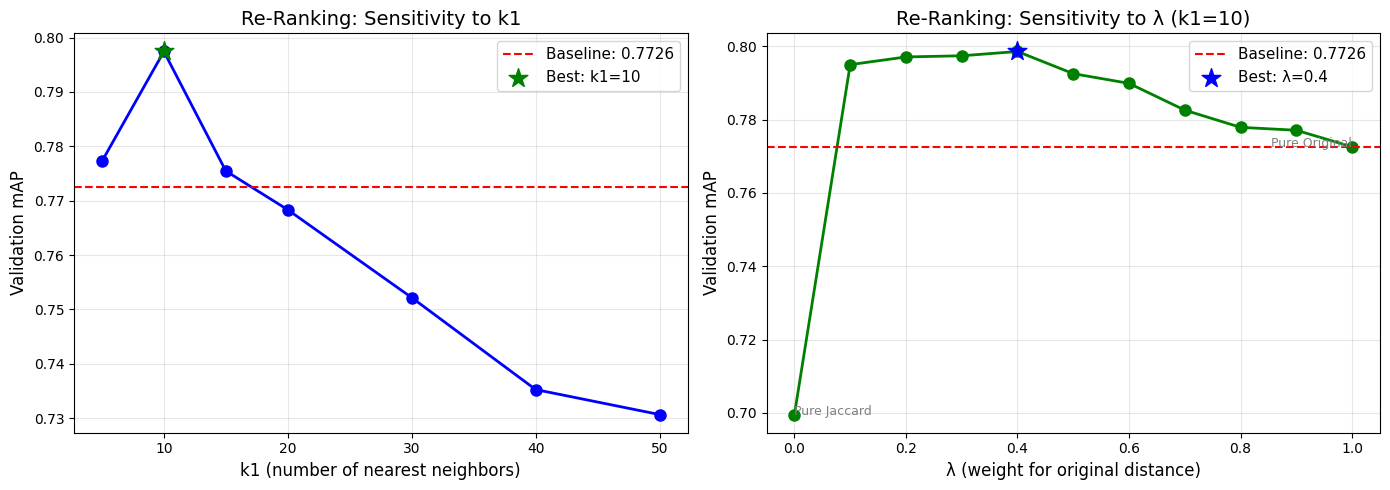

In [22]:
# Plot hyperparameter sensitivity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# k1 sweep
axes[0].plot(k1_values, k1_results, 'bo-', linewidth=2, markersize=8)
axes[0].axhline(y=baseline_map, color='r', linestyle='--', label=f'Baseline: {baseline_map:.4f}')
axes[0].set_xlabel('k1 (number of nearest neighbors)', fontsize=12)
axes[0].set_ylabel('Validation mAP', fontsize=12)
axes[0].set_title('Re-Ranking: Sensitivity to k1', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
# Mark best k1
best_k1_map = max(k1_results)
axes[0].scatter([best_k1], [best_k1_map], color='green', s=200, zorder=5, marker='*', label=f'Best: k1={best_k1}')
axes[0].legend(fontsize=11)

# Lambda sweep
axes[1].plot(lambda_values, lambda_results, 'go-', linewidth=2, markersize=8)
axes[1].axhline(y=baseline_map, color='r', linestyle='--', label=f'Baseline: {baseline_map:.4f}')
axes[1].set_xlabel('λ (weight for original distance)', fontsize=12)
axes[1].set_ylabel('Validation mAP', fontsize=12)
axes[1].set_title(f'Re-Ranking: Sensitivity to λ (k1={best_k1})', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
# Mark best lambda
best_lambda_map = max(lambda_results)
axes[1].scatter([best_lambda], [best_lambda_map], color='blue', s=200, zorder=5, marker='*', label=f'Best: λ={best_lambda}')
axes[1].legend(fontsize=11)

# Add annotation: lambda=0 means pure Jaccard, lambda=1 means pure original distance
axes[1].annotate('Pure Jaccard', xy=(0.0, lambda_results[0]), fontsize=9, color='gray')
axes[1].annotate('Pure Original', xy=(1.0, lambda_results[-1]), fontsize=9, color='gray', ha='right')

plt.tight_layout()
wandb.log({"reranking_sensitivity": wandb.Image(fig)})
plt.show()

# Log sweep results as W&B table
sweep_df = pd.DataFrame({
    'k1': k1_values,
    'mAP': k1_results,
    'improvement': [m - baseline_map for m in k1_results]
})
wandb.log({"k1_sweep_table": wandb.Table(dataframe=sweep_df)})

lambda_sweep_df = pd.DataFrame({
    'lambda': lambda_values,
    'mAP': lambda_results,
    'improvement': [m - baseline_map for m in lambda_results]
})
wandb.log({"lambda_sweep_table": wandb.Table(dataframe=lambda_sweep_df)})

In [23]:
# Final re-ranking with best hyperparameters
print(f"\nFinal re-ranking with best hyperparameters: k1={best_k1}, lambda={best_lambda}")
final_reranked_dist = k_reciprocal_rerank(
    val_original_dist,
    k1=best_k1,
    k2=config["rerank_k2"],
    lambda_value=best_lambda
)
final_reranked_map = compute_map_from_distance_matrix(final_reranked_dist, val_labels)

print(f"\n{'='*50}")
print(f"RESULTS SUMMARY")
print(f"{'='*50}")
print(f"Baseline mAP (cosine sim):         {baseline_map:.4f}")
print(f"Re-Ranked mAP (best params):       {final_reranked_map:.4f}")
print(f"Absolute improvement:              {final_reranked_map - baseline_map:+.4f}")
print(f"Relative improvement:              {(final_reranked_map - baseline_map) / baseline_map * 100:+.2f}%")
print(f"{'='*50}")
print(f"Best k1: {best_k1}")
print(f"Best lambda: {best_lambda}")

wandb.run.summary["best_rerank_k1"] = best_k1
wandb.run.summary["best_rerank_lambda"] = best_lambda
wandb.run.summary["best_val_mAP_reranked"] = final_reranked_map
wandb.run.summary["reranking_improvement_abs"] = final_reranked_map - baseline_map
wandb.run.summary["reranking_improvement_pct"] = (final_reranked_map - baseline_map) / baseline_map * 100


Final re-ranking with best hyperparameters: k1=10, lambda=0.4


Computing Jaccard distances:   0%|          | 0/379 [00:00<?, ?it/s]


RESULTS SUMMARY
Baseline mAP (cosine sim):         0.7726
Re-Ranked mAP (best params):       0.7986
Absolute improvement:              +0.0260
Relative improvement:              +3.37%
Best k1: 10
Best lambda: 0.4


## 11. Generate Competition Submission (with Re-Ranking)

In [24]:
# Load test pairs
test_pairs_df = pd.read_csv(config["data_dir"] / "test.csv")
print(f"Test pairs to score: {len(test_pairs_df)}")
print(test_pairs_df.head())

# Get unique test images
test_images = sorted(list(set(test_pairs_df['query_image'].unique()) | set(test_pairs_df['gallery_image'].unique())))
print(f"\nUnique test images: {len(test_images)}")

# Extract MegaDescriptor embeddings for test images
test_image_paths = [config["data_dir"] / "test/test" / filename for filename in test_images]

print(f"Extracting MegaDescriptor embeddings for test images...")
test_mega_embeddings = extract_embeddings(
    megadescriptor, test_image_paths, batch_size=config["batch_size"], desc="Test embeddings"
)
print(f"Test MegaDescriptor embeddings shape: {test_mega_embeddings.shape}")

Test pairs to score: 137270
   row_id    query_image  gallery_image
0       0  test_0001.png  test_0002.png
1       1  test_0001.png  test_0003.png
2       2  test_0001.png  test_0004.png
3       3  test_0001.png  test_0005.png
4       4  test_0001.png  test_0006.png

Unique test images: 371
Extracting MegaDescriptor embeddings for test images...


Test embeddings:   0%|          | 0/12 [00:00<?, ?it/s]

Test MegaDescriptor embeddings shape: (371, 1536)


In [25]:
# Project through fine-tuned model
model.eval()
with torch.no_grad():
    test_tensor = torch.FloatTensor(test_mega_embeddings).to(device)
    test_finetuned_embeddings = model.get_embeddings(test_tensor).cpu().numpy()

print(f"Fine-tuned test embeddings shape: {test_finetuned_embeddings.shape}")

# Compute original distance matrix for test images
print("Computing pairwise cosine similarity for all test images...")
test_sim_matrix = cosine_similarity(test_finetuned_embeddings)
test_original_dist = 1.0 - test_sim_matrix
np.fill_diagonal(test_original_dist, 0.0)

print(f"Test distance matrix shape: {test_original_dist.shape}")

Fine-tuned test embeddings shape: (371, 256)
Computing pairwise cosine similarity for all test images...
Test distance matrix shape: (371, 371)


In [26]:
# Apply re-ranking on test set with best hyperparameters
print(f"Applying k-reciprocal re-ranking to test set (k1={best_k1}, k2={config['rerank_k2']}, lambda={best_lambda})...")
test_reranked_dist = k_reciprocal_rerank(
    test_original_dist,
    k1=best_k1,
    k2=config["rerank_k2"],
    lambda_value=best_lambda
)

# Convert re-ranked distances back to similarities
# Use exp(-dist) to convert distance to similarity, then normalize to [0, 1]
test_reranked_sim = np.exp(-test_reranked_dist)

# Create mapping from filename to index
img_to_idx = {filename: idx for idx, filename in enumerate(test_images)}

print("Re-ranking complete.")

Applying k-reciprocal re-ranking to test set (k1=10, k2=6, lambda=0.4)...


Computing Jaccard distances:   0%|          | 0/371 [00:00<?, ?it/s]

Re-ranking complete.


In [27]:
# Generate both submissions: baseline (cosine) and re-ranked
similarities_baseline = []
similarities_reranked = []

for _, row in tqdm(test_pairs_df.iterrows(), total=len(test_pairs_df), desc="Computing similarities"):
    q_idx = img_to_idx[row['query_image']]
    g_idx = img_to_idx[row['gallery_image']]

    # Baseline: cosine similarity
    sim_baseline = test_sim_matrix[q_idx, g_idx]
    similarities_baseline.append(sim_baseline)

    # Re-ranked: converted from re-ranked distance
    sim_reranked = test_reranked_sim[q_idx, g_idx]
    similarities_reranked.append(sim_reranked)

similarities_baseline = np.clip(np.array(similarities_baseline), 0.0, 1.0)
similarities_reranked = np.clip(np.array(similarities_reranked), 0.0, 1.0)

print(f"\nBaseline similarity stats:")
print(f"  Min: {similarities_baseline.min():.4f}, Max: {similarities_baseline.max():.4f}, Mean: {similarities_baseline.mean():.4f}")

print(f"\nRe-ranked similarity stats:")
print(f"  Min: {similarities_reranked.min():.4f}, Max: {similarities_reranked.max():.4f}, Mean: {similarities_reranked.mean():.4f}")

Computing similarities:   0%|          | 0/137270 [00:00<?, ?it/s]


Baseline similarity stats:
  Min: 0.0000, Max: 0.9945, Mean: 0.0623

Re-ranked similarity stats:
  Min: 0.3062, Max: 0.9891, Mean: 0.3746


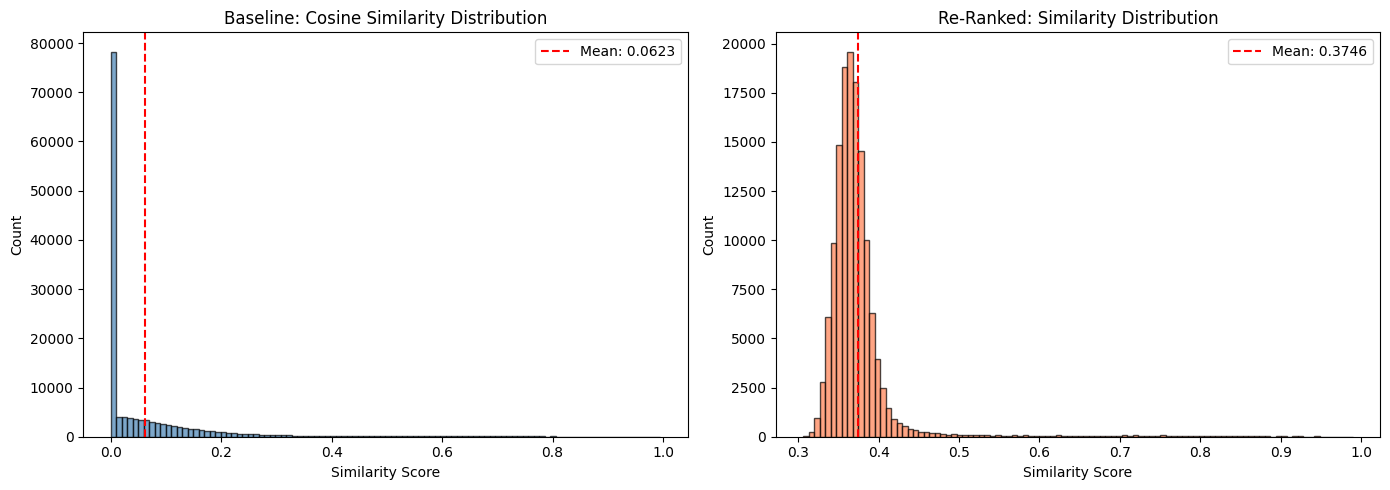

In [28]:
# Visualize similarity distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(similarities_baseline, bins=100, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Similarity Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Baseline: Cosine Similarity Distribution')
axes[0].axvline(x=similarities_baseline.mean(), color='red', linestyle='--', label=f'Mean: {similarities_baseline.mean():.4f}')
axes[0].legend()

axes[1].hist(similarities_reranked, bins=100, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_xlabel('Similarity Score')
axes[1].set_ylabel('Count')
axes[1].set_title('Re-Ranked: Similarity Distribution')
axes[1].axvline(x=similarities_reranked.mean(), color='red', linestyle='--', label=f'Mean: {similarities_reranked.mean():.4f}')
axes[1].legend()

plt.tight_layout()
wandb.log({"similarity_distributions": wandb.Image(fig)})
plt.show()

In [29]:
# Save re-ranked submission
submission_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities_reranked
})

submission_path = config["checkpoint_dir"] / "submission.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Re-ranked submission saved to: {submission_path}")
print(f"File size: {submission_path.stat().st_size / 1024:.1f} KB")

# Also save baseline submission for comparison
submission_baseline_df = pd.DataFrame({
    'row_id': test_pairs_df['row_id'],
    'similarity': similarities_baseline
})

submission_baseline_path = config["checkpoint_dir"] / "submission_baseline.csv"
submission_baseline_df.to_csv(submission_baseline_path, index=False)
print(f"Baseline submission saved to: {submission_baseline_path}")

Re-ranked submission saved to: checkpoints_reranking/submission.csv
File size: 2259.2 KB
Baseline submission saved to: checkpoints_reranking/submission_baseline.csv


## 12. Save Artifacts to W&B

In [30]:
# Save model artifact
model_artifact = wandb.Artifact(
    name="arcface-model-reranking",
    type="model",
    description="ArcFace model with k-reciprocal re-ranking post-processing"
)
model_artifact.add_file(str(config["checkpoint_dir"] / "arcface_best.pth"))
wandb.log_artifact(model_artifact)

# Save submission artifact
submission_artifact = wandb.Artifact(
    name="submission-reranking",
    type="submission",
    description="Competition submission with k-reciprocal re-ranking"
)
submission_artifact.add_file(str(submission_path))
wandb.log_artifact(submission_artifact)

print("Artifacts saved to W&B")

Artifacts saved to W&B


In [31]:
# Finish W&B run
wandb.finish()
print("W&B run completed")

wandb: uploading artifact arcface-model-reranking; uploading artifact submission-reranking; updating run metadata
wandb: uploading artifact arcface-model-reranking; uploading artifact submission-reranking; uploading config.yaml
wandb: uploading artifact arcface-model-reranking; uploading artifact submission-reranking
wandb: uploading artifact submission-reranking
wandb: uploading history steps 57-57, summary, console lines 411-420
wandb: 
wandb: Run history:
wandb:               epoch ▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
wandb:       learning_rate ▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      num_parameters ▁
wandb:           train_acc ▁▁▁▁▂▂▂▃▃▄▄▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█▇█████
wandb:          train_loss █▆▆▅▅▄▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:             val_acc ▁▂▂▃▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇███████████████
wandb:            val_loss █▇▆▅▅▄▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:             val_map ▁▁▂▂▃▄▄▄▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇████████
wandb:    val_map_baseline ▁
wan

W&B run completed


## Summary

This experiment evaluated **k-reciprocal re-ranking** as a post-processing step for jaguar re-identification.

### Method
- **Training**: Identical to baseline (MegaDescriptor-L-384 → ArcFace, frozen backbone)
- **Post-processing**: k-reciprocal encoding (Zhong et al., CVPR 2017) refines pairwise similarities by exploiting the neighborhood structure of the embedding space

### Key Components
1. **k-Reciprocal Neighbors**: Mutual nearest neighbors provide high-confidence matches
2. **Local Query Expansion**: Expands the reciprocal set by incorporating neighbors with high overlap
3. **Jaccard Distance**: Measures similarity between neighborhood encodings
4. **Distance Fusion**: Combines original cosine distance with Jaccard distance via weight λ

### Hyperparameters
- `k1`: Number of nearest neighbors for reciprocal set construction
- `k2`: Number of neighbors for local query expansion
- `lambda`: Weight balancing original vs. Jaccard distance (0 = pure Jaccard, 1 = pure original)

### Advantages
- No additional training required — purely post-processing
- Exploits global structure of the embedding space
- Can be combined with any embedding model
- Standard technique in re-identification literature

### Potential Limitations
- Computational cost: O(N²) for pairwise distance computation and Jaccard encoding
- Requires all gallery embeddings at inference time (not applicable to streaming scenarios)
- Effectiveness depends on the quality of initial embeddings